In [112]:
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from typing_extensions import   TypedDict
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
import sqlite3 
from langgraph.checkpoint.sqlite import SqliteSaver
from langchain_google_genai import GoogleGenerativeAIEmbeddings
import os   
import requests

In [113]:
load_dotenv(override=True)
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")


In [114]:
class SubState(TypedDict):
    input_text: str
    translated_text:str

In [115]:
subgraph_llm = ChatGroq(model="llama-3.3-70b-versatile")

In [116]:
def translate_text(state:SubState):
    prompt=f"""
    translate the follwing into Hindi language.
    Keep it natural and clear . Do Not Add extra content.

    text:
    {state["input_text"]}
    """.strip()

    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text' : translated_text}

In [117]:
subgraph_builder = StateGraph(SubState)
subgraph_builder.add_node('translate_text',translate_text)
subgraph_builder.add_edge(START,'translate_text')

subgraph_builder.add_edge('translate_text',END)

subgraph = subgraph_builder.compile()

In [118]:
class ParentState(TypedDict):
    question:str
    answer_eng:str
    answer_hin:str

In [119]:
parent_llm = ChatGroq(model="llama-3.3-70b-versatile")


In [120]:
def generate_answer(state: ParentState):
    answer = parent_llm.invoke(f"you are a helpful assistant .n\nQuestion : {state['question']} ").content
    return {'answer_eng':answer}

In [121]:
def translate_answer(state: ParentState):
    #call the subgrapth ( having functionality to translate the answer to hindi language ...)

    result = subgraph.invoke({'input_text' : state['answer_eng']})

    return {'answer_hin': result['translated_text']}
    

In [122]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node('answer',generate_answer)
parent_builder.add_node('translate_answer',translate_answer)

parent_builder.add_edge(START,'answer')
parent_builder.add_edge('answer','translate_answer')
parent_builder.add_edge('translate_answer',END)

graph = parent_builder.compile()

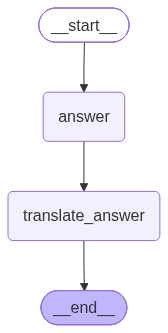

In [123]:
graph

In [124]:
graph.invoke({'question':'what is AI '})


{'question': 'what is AI ',
 'answer_eng': '**What is AI?**\n\nAI stands for Artificial Intelligence, which refers to the development of computer systems that can perform tasks that would typically require human intelligence, such as:\n\n1. **Learning**: AI systems can learn from data and improve their performance over time.\n2. **Reasoning**: AI systems can draw inferences, make decisions, and solve problems using logical rules.\n3. **Problem-solving**: AI systems can identify and solve complex problems, often more efficiently than humans.\n4. **Perception**: AI systems can interpret and understand data from sensors, such as images, speech, and text.\n\nThe goal of AI is to create systems that can think and act like humans, but with the ability to process vast amounts of data, recognize patterns, and make decisions faster and more accurately.\n\n**Types of AI:**\n\n1. **Narrow or Weak AI**: Designed to perform a specific task, such as image recognition, language translation, or playin